**0. Imports:**

In [1]:
import earthcarekit as eck
eck.set_config("/usr/people/raucher/Documents/Config_ECK/default_config.toml")
import xarray as xr
xr.set_options(display_expand_data_vars=True, display_max_rows=500, display_max_items=10000)
import re
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d 
import sys
import shlex
import shutil
from datetime import date
import importlib.util

Default config set at </usr/people/raucher/.config/earthcarekit/default_config.toml>


**0b. Remote ZIP Helpers (check_run + my_subprocess)**


In [2]:

# --- Remote ZIP ingest helpers ---
# This block replaces the external check_run.py flow directly inside the notebook.
# Workflow: discover remote ZIPs -> copy 1 ZIP locally -> unzip -> process .h5 -> delete local temp data.

# Import command runner from my_subprocess.py
MY_SUBPROCESS_FILE = Path("/usr/people/raucher/Documents/Coding1/Gerd-Jan/OneDrive_1_24-2-2026")
if str(MY_SUBPROCESS_FILE) not in sys.path:
    sys.path.insert(0, str(MY_SUBPROCESS_FILE))

from my_subprocess import run_shell_cmd_and_communicate, print_shell_output


def _to_date(v):
    """Normalize date/datetime/string to a date object."""
    if isinstance(v, datetime):
        return v.date()
    if isinstance(v, date):
        return v
    if isinstance(v, str):
        return datetime.strptime(v, "%Y-%m-%d").date()
    raise TypeError(f"Unsupported date type: {type(v)}")


def run_cmd_checked(cmd: str, verbose: bool = False):
    """Run shell command via my_subprocess; raise if command fails."""
    lines_out, lines_err, rc = run_shell_cmd_and_communicate(cmd, verbose=verbose)
    if rc != 0:
        print_shell_output(lines_out, lines_err, prefix="[shell] ")
        raise RuntimeError(f"Command failed (exit {rc}): {cmd}")
    return lines_out, lines_err


def discover_remote_zip_files(remote_product_root, start_date, end_date):
    """Discover .ZIP/.zip files in YYYY/MM/DD folders in [start_date, end_date]."""
    root = Path(remote_product_root)
    start = _to_date(start_date)
    end = _to_date(end_date)
    if end < start:
        raise ValueError("end_date must be >= start_date")

    zips = []
    day = start
    while day <= end:
        day_dir = root / day.strftime("%Y") / day.strftime("%m") / day.strftime("%d")
        if day_dir.exists():
            zips.extend(sorted(day_dir.glob("*.ZIP")))
            zips.extend(sorted(day_dir.glob("*.zip")))
        day += timedelta(days=1)

    # Keep deterministic order and remove duplicates if both patterns matched same file.
    return sorted(dict.fromkeys(zips))


def stage_zip_and_extract(src_zip: Path, local_stage_root: Path):
    """
    Copy one remote ZIP to local stage, extract it, and return extracted .h5 files.
    """
    local_stage_root.mkdir(parents=True, exist_ok=True)
    local_zip = local_stage_root / src_zip.name
    extract_dir = local_stage_root / src_zip.stem

    # Ensure clean stage for this ZIP.
    if local_zip.exists():
        local_zip.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    run_cmd_checked(f"cp {shlex.quote(str(src_zip))} {shlex.quote(str(local_zip))}")
    run_cmd_checked(f"unzip -oq {shlex.quote(str(local_zip))} -d {shlex.quote(str(extract_dir))}")

    h5_files = sorted(extract_dir.rglob("*.h5"))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 after extracting: {src_zip}")

    return local_zip, extract_dir, h5_files


def cleanup_staged_data(local_zip: Path | None, extract_dir: Path | None):
    """Delete only local staged ZIP + extracted folder (never remote source files)."""
    if extract_dir is not None and extract_dir.exists():
        shutil.rmtree(extract_dir)
    if local_zip is not None and local_zip.exists():
        local_zip.unlink()


**1. Config**

In [3]:

# Input data
REMOTE_PRODUCT_ROOT = Path("/net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A")

# Local staging folder for temporary ZIP/extracted data (safe to clean up)
LOCAL_STAGE_ROOT = Path("/usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2A")
LOCAL_STAGE_ROOT.mkdir(parents=True, exist_ok=True)

START_DATE = "2025-01-01"   # YYYY-MM-DD
END_DATE   = "2026-02-28"   # YYYY-MM-DD

# Output
OUTPUT_ROOT = Path("/usr/people/raucher/Documents/Coding1/KNMI/KNMI/ATC_output")

# Classification settings
CLASS_VAR    = "classification"
TARGET_CLASS = 3     # Ice Cloud
GROUND_CODE  = -2    # surface/sub-surface (always excluded from denominator)
MISSING_CODE = -3    # Missing Data (always excluded from denominator)

# tc=-1 (noise in both Mie and Ray channels): excluded when True, included when False
EXCLUDE_NOISE_CLASS = True

# Quality filter: pixels with quality_status > MAX_QC_FLAG are excluded from both
# numerator and denominator.
# 0=Good  1=Likely Good (degraded/low SNR)  2=Likely Bad  3=Bad/attenuated  4=Missing L1
QC_VAR      = "quality_status"
MAX_QC_FLAG = 1    # accept 0 and 1; reject 2, 3, 4

# Coordinate variables
LAT        = "latitude"
LON        = "longitude"
HEIGHT_VAR = "height"

GRID_RES_DEG         = 1.0
MAX_HEIGHT_M         = 20_000.0   # ice clouds not expected above 20 km
MIN_SAMPLES_PER_CELL = 10

start_dt = datetime.strptime(START_DATE, "%Y-%m-%d").date()
end_dt   = datetime.strptime(END_DATE,   "%Y-%m-%d").date()
if end_dt < start_dt:
    raise ValueError("END_DATE must be >= START_DATE")

if not REMOTE_PRODUCT_ROOT.exists():
    raise FileNotFoundError(f"Remote path not mounted/reachable: {REMOTE_PRODUCT_ROOT}")

RUN_LABEL = f"ATL_TC_2A_icecloud_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}_{GRID_RES_DEG:.1f}deg"

print("Config loaded")
print(f"Product:     ATL_TC__2A")
print(f"Remote root: {REMOTE_PRODUCT_ROOT}")
print(f"Stage root:  {LOCAL_STAGE_ROOT}")
print(f"Date range:  {start_dt} to {end_dt}")
print(f"CLASS_VAR={CLASS_VAR!r}  TARGET_CLASS={TARGET_CLASS}  GROUND_CODE={GROUND_CODE}")
print(f"EXCLUDE_NOISE_CLASS (tc=-1): {EXCLUDE_NOISE_CLASS}")
print(f"MAX_HEIGHT_M={MAX_HEIGHT_M:.0f} m  GRID_RES_DEG={GRID_RES_DEG}")


Config loaded
Product:     ATL_TC__2A
Remote root: /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A
Stage root:  /usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2A
Date range:  2025-01-01 to 2026-02-28
CLASS_VAR='classification'  TARGET_CLASS=3  GROUND_CODE=-2
EXCLUDE_NOISE_CLASS (tc=-1): True
MAX_HEIGHT_M=20000 m  GRID_RES_DEG=1.0


**2. File Discovery**

In [4]:

zip_paths = discover_remote_zip_files(REMOTE_PRODUCT_ROOT, start_dt, end_dt)

print(f"Discovered {len(zip_paths)} ZIP files  |  Range: {start_dt} -> {end_dt}")
for p in zip_paths[:3]:
    print("  -", p)
if len(zip_paths) > 3:
    print(f"  ... and {len(zip_paths)-3} more")

if len(zip_paths) == 0:
    raise FileNotFoundError("No ZIP files found for this date range/product.")


Discovered 51274 ZIP files  |  Range: 2025-01-01 -> 2026-02-28
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A/2025/01/01/ECA_EXBA_ATL_TC__2A_20250101T000823Z_20250918T221201Z_03377D.ZIP
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A/2025/01/01/ECA_EXBA_ATL_TC__2A_20250101T002009Z_20250918T223350Z_03377E.ZIP
  - /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A/2025/01/01/ECA_EXBA_ATL_TC__2A_20250101T003144Z_20250918T225015Z_03377F.ZIP
  ... and 51271 more


**3. Single-File Inspection**

In [5]:

# Stage one ZIP locally for inspection, then clean up local temporary data
local_zip = None
extract_dir = None

try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    fp0 = str(staged_h5[0])
    print("Inspecting staged file:", fp0)

    with eck.read_product(fp0) as ds0:
        # Basic overview
        print("\nDataset summary:")
        print("height shape:", ds0[HEIGHT_VAR].shape)
        display(ds0)

        # Show dimension sizes
        print("\nDimensions:")
        for k, v in ds0.sizes.items():
            print(f" - {k}: {v}")

        # List available data variables in this product
        print("\nData variables:")
        for name in ds0.data_vars:
            print(" -", name)

        # Check the key variables
        required_vars = [CLASS_VAR, LAT, HEIGHT_VAR, LON]

        print("\nRequired variable check:")
        for v in required_vars:
            print(f" - {v}: {'OK' if v in ds0.data_vars else 'MISSING'}")

        # Show target classification definition nicely
        print("\nClassification metadata:")
        print("long_name:", ds0[CLASS_VAR].attrs.get("long_name", "n/a"))
        definition = ds0[CLASS_VAR].attrs.get("definition", "n/a")
        print("definition:")
        print(definition)

        # Parse code -> meaning from the definition text
        code_to_meaning = {}
        for line in definition.splitlines():
            line = line.strip()
            if not line:
                continue
            m = re.match(r"^([-\d:]+)\s*:\s*(.+)$", line)
            if not m:
                continue

            code_token, meaning = m.groups()
            if code_token.lstrip("-").isdigit():
                code_to_meaning[int(code_token)] = meaning
            elif ":" in code_token:
                a, b = code_token.split(":", 1)
                if a.lstrip("-").isdigit() and b.lstrip("-").isdigit():
                    a, b = int(a), int(b)
                    step = 1 if b >= a else -1
                    for c in range(a, b + step, step):
                        code_to_meaning[c] = meaning

        # Count classes present in this file
        cls_vals = ds0[CLASS_VAR].values
        unique_codes = (
            pd.Series(cls_vals.ravel())
            .dropna()
            .astype(int)
            .value_counts()
            .sort_index()
            .rename("count")
            .reset_index()
            .rename(columns={"index": "target_class_code"})
        )
        unique_codes.insert(
            0,
            "target_class_name",
            unique_codes["target_class_code"].map(code_to_meaning).fillna("Unknown"),
        )
        print("\nUnique class codes in this file (name | code | count):")
        display(unique_codes)
finally:
    cleanup_staged_data(local_zip, extract_dir)


Inspecting staged file: /usr/people/raucher/Documents/Coding1/KNMI/KNMI/temp_ZIPs_2A/ECA_EXBA_ATL_TC__2A_20250101T000823Z_20250918T221201Z_03377D/ECA_EXBA_ATL_TC__2A_20250101T000823Z_20250918T221201Z_03377D/ECA_EXBA_ATL_TC__2A_20250101T000823Z_20250918T221201Z_03377D.h5

Dataset summary:
height shape: (4945, 242)


<xarray.Dataset> Size: 70MB
Dimensions:                                                  (
                                                              along_track: 4945,
                                                              vertical: 242,
                                                              class: 7)
Dimensions without coordinates: along_track, vertical, class
Data variables:
    filename                                                 <U60 240B ...
    file_type                                                <U10 40B ...
    frame_id                                                 <U1 4B 'D'
    orbit_number                                             uint32 4B 3377
    orbit_and_frame                                          <U6 24B '03377D'
    baseline                                                 <U2 8B 'BA'
    sensing_start_time                                       datetime64[ns] 8B ...
    processing_start_time                                    datetime64[ns] 8B ...
    trim_index_offset                                        int64 8B 98
    medium_resolution_number_of_joint_standard_grid_pixels   int16 2B 11
    low_resolution_number_of_joint_standard_grid_pixels      int16 2B 101
    joint_standard_grid_index                                (along_track) int32 20kB ...
    latitude                                                 (along_track) float64 40kB ...
    longitude                                                (along_track) float64 40kB ...
    time                                                     (along_track) datetime64[ns] 40kB ...
    height                                                   (along_track, vertical) float32 5MB ...
    range                                                    (along_track, vertical) float32 5MB ...
    viewing_elevation_angle                                  (along_track) float32 20kB ...
    elevation                                                (along_track) float32 20kB ...
    tropopause_height                                        (along_track) float32 20kB ...
    geoid_offset                                             (along_track) float32 20kB ...
    simple_classification                                    (along_track, vertical) int8 1MB ...
    mie_detection_status                                     (along_track, vertical) int8 1MB ...
    rayleigh_detection_status                                (along_track, vertical) int8 1MB ...
    extended_data_quality_status                             (along_track, vertical) int8 1MB ...
    quality_status                                           (along_track, vertical) int8 1MB ...
    aerosol_classes                                          (class) |S32 224B ...
    aerosol_classification_prob                              (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_medium_resolution            (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_low_resolution               (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_no_errors                    (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_no_errors_medium_resolution  (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_no_errors_low_resolution     (along_track, vertical, class) int8 8MB ...
    classification                                           (along_track, vertical) int8 1MB ...
    classification_medium_resolution                         (along_track, vertical) int8 1MB ...
    classification_low_resolution                            (along_track, vertical) int8 1MB ...


Dimensions:
 - along_track: 4945
 - vertical: 242
 - class: 7

Data variables:
 - filename
 - file_type
 - frame_id
 - orbit_number
 - orbit_and_frame
 - baseline
 - sensing_start_time
 - processing_start_time
 - trim_index_offset
 - medium_resolution_number_of_joint_standard_grid_pixels
 - low_resolution_number_of_joint_standard_grid_pixels
 - joint_standard_grid_index
 - latitude
 - longitude
 - time
 - height
 - range
 - viewing_elevation_angle
 - elevation
 - tropopause_height
 - geoid_offset
 - simple_classification
 - mie_detection_status
 - rayleigh_detection_status
 - extended_data_quality_status
 - quality_status
 - aerosol_classes
 - aerosol_classification_prob
 - aerosol_classification_prob_medium_resolution
 - aerosol_classification_prob_low_resolution
 - aerosol_classification_prob_no_errors
 - aerosol_classification_prob_no_errors_medium_resolution
 - aerosol_classification_prob_no_errors_low_resolution
 - classification
 - classification_medium_resolution
 - classificat

,target_class_name,target_class_code,count
0,Surface or sub-surface,-2,43273
1,Noise in both Mie and Ray Channels,-1,57222
2,Clear,0,994717
3,(Warm) Liquid Cloud,1,4409
4,(Supercooled) Liquid Cloud,2,7859
5,Ice Cloud,3,47199
6,Dust,10,304
7,Sea_salt,11,20265
8,Continental_Pollution,12,1801
9,Smoke,13,5249


**4. Grid Setup**

In [6]:
# Global lat/lon bins
lat_bins = np.arange(-90.0, 90.0 + GRID_RES_DEG, GRID_RES_DEG)
lon_bins = np.arange(-180.0, 180.0 + GRID_RES_DEG, GRID_RES_DEG)

lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lon_centers = 0.5 * (lon_bins[:-1] + lon_bins[1:])

n_lat = len(lat_centers)
n_lon = len(lon_centers)

assert np.isclose(lat_bins[1] - lat_bins[0], GRID_RES_DEG)
assert np.isclose(lon_bins[1] - lon_bins[0], GRID_RES_DEG)

# Fixed height axis aligned to the EarthCARE ATLID Joint Standard Grid (JSG):
# 100 m vertical spacing from 0 to MAX_HEIGHT_M (troposphere / lower stratosphere).
target_h = np.arange(0.0, MAX_HEIGHT_M + 1.0, 100.0)   # e.g. 201 levels: 0..20000 m
n_height  = target_h.size

# 3D accumulators: ice occurrence
total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d   = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

print("Grid ready")
print(f"Shape (lat, lon, height): {total_count_3d.shape}")
print(f"Height range: {float(np.nanmin(target_h)):.0f} .. {float(np.nanmax(target_h)):.0f} m")
print(f"Latitude centers:  {lat_centers[0]} .. {lat_centers[-1]}")
print(f"Longitude centers: {lon_centers[0]} .. {lon_centers[-1]}")

assert target_h.ndim == 1 and len(target_h) == n_height
assert np.nanmax(target_h) <= MAX_HEIGHT_M

Grid ready
Shape (lat, lon, height): (180, 360, 201)
Height range: 0 .. 20000 m
Latitude centers:  -89.5 .. 89.5
Longitude centers: -179.5 .. 179.5


**5. One-File Accumulator**

In [7]:
"""
Process one ATL_TC__2A file and accumulate ice cloud occurrence counts
on a (lat, lon, height) grid. Temperature extraction is omitted to support
older files that do not contain temperature data.

Valid pixels (denominator): finite height & classification, tc != GROUND_CODE,
  optionally tc != -1 (noise).
Ice pixels (numerator): tc == TARGET_CLASS (3).
"""

def accumulate_one_file(fp, lat_bins, lon_bins, target_h):
    with eck.read_product(str(fp)) as ds:
        cls = ds[CLASS_VAR].values.astype(float)
        h   = ds[HEIGHT_VAR].values
        lat = ds[LAT].values
        lon = ds[LON].values
        qc  = ds[QC_VAR].values.astype(int)

        n_obs    = cls.shape[0]
        n_height = target_h.size
        ice_interp = np.full((n_obs, n_height), np.nan, dtype=float)

        for i in range(n_obs):
            h_i   = h[i, :]
            cls_i = cls[i, :]
            qc_i  = qc[i, :]

            valid = (np.isfinite(h_i) & np.isfinite(cls_i)
                     & (cls_i != GROUND_CODE)
                     & (cls_i != MISSING_CODE)
                     & (qc_i  <= MAX_QC_FLAG))
            if EXCLUDE_NOISE_CLASS:
                valid &= (cls_i != -1)
            if np.sum(valid) < 2:
                continue

            h_v   = h_i[valid]
            ice_v = (cls_i[valid] == TARGET_CLASS).astype(float)

            order = np.argsort(h_v)
            h_v, ice_v = h_v[order], ice_v[order]
            h_v, idx = np.unique(h_v, return_index=True)
            ice_v = ice_v[idx]
            if h_v.size < 2:
                continue

            ice_interp[i, :] = interp1d(h_v, ice_v, kind="nearest",
                                         bounds_error=False, fill_value=np.nan)(target_h)

    total_hist_3d = np.zeros((len(lat_bins)-1, len(lon_bins)-1, n_height), dtype=np.float64)
    ice_hist_3d   = np.zeros_like(total_hist_3d)

    lat2d = np.broadcast_to(lat[:, None], ice_interp.shape)
    lon2d = np.broadcast_to(lon[:, None], ice_interp.shape)

    for k in range(n_height):
        v = ice_interp[:, k]
        m = np.isfinite(v) & np.isfinite(lat2d[:, k]) & np.isfinite(lon2d[:, k])
        if not np.any(m):
            continue
        total_k, _, _ = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m],
                                        bins=[lat_bins, lon_bins])
        ice_k, _, _   = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m],
                                        bins=[lat_bins, lon_bins],
                                        weights=(v[m] == 1).astype(float))
        total_hist_3d[:, :, k] = total_k
        ice_hist_3d[:, :, k]   = ice_k

    return total_hist_3d, ice_hist_3d


### TEST ###
local_zip = None
extract_dir = None
try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    t1, i1 = accumulate_one_file(staged_h5[0], lat_bins, lon_bins, target_h)
    print("one-file total pixels:", int(np.nansum(t1)))
    print("one-file ice pixels:  ", int(np.nansum(i1)))
    print("shape:", t1.shape)
finally:
    cleanup_staged_data(local_zip, extract_dir)

one-file total pixels: 915169
one-file ice pixels:   49832
shape: (180, 360, 201)


**6. Few File Test run**

Tested ZIPs: 5  |  H5 processed: 5  |  Failed: 0
Total valid pixels: 4462902
Total ice pixels:   170809
Overall ice occurrence (test): 0.038273078817325584


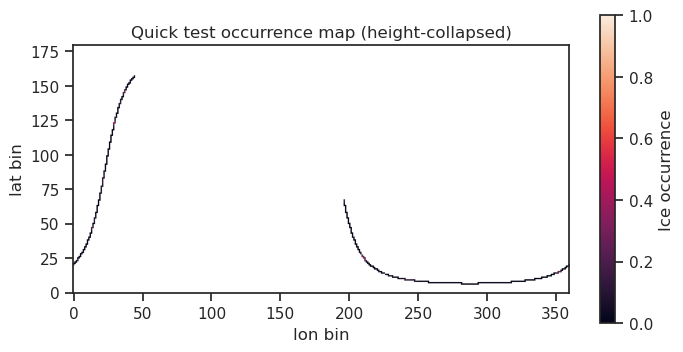

In [8]:
N_QUICK_TEST = min(5, len(zip_paths))

total_test = np.zeros_like(total_count_3d)
ice_test   = np.zeros_like(ice_count_3d)
failed_test       = []
processed_h5_test = 0

for src_zip in zip_paths[:N_QUICK_TEST]:
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)
        for fp in h5_files:
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            total_test += t3d
            ice_test   += i3d
            processed_h5_test += 1
    except Exception as e:
        failed_test.append((str(src_zip), str(e)))
    finally:
        cleanup_staged_data(local_zip, extract_dir)

print(f"Tested ZIPs: {N_QUICK_TEST}  |  H5 processed: {processed_h5_test}  |  Failed: {len(failed_test)}")
print("Total valid pixels:", int(np.nansum(total_test)))
print("Total ice pixels:  ", int(np.nansum(ice_test)))
if np.nansum(total_test) > 0:
    print("Overall ice occurrence (test):", float(np.nansum(ice_test) / np.nansum(total_test)))

if failed_test:
    print("\nFirst failure:", failed_test[0][1])

# Quick look
num2d = np.nansum(ice_test,   axis=2)
den2d = np.nansum(total_test, axis=2)
occ2d = np.divide(num2d, den2d, out=np.full_like(num2d, np.nan), where=den2d > 0)

plt.figure(figsize=(8, 4))
plt.imshow(occ2d, origin="lower", vmin=0, vmax=1)
plt.colorbar(label="Ice occurrence")
plt.title("Quick test occurrence map (height-collapsed)")
plt.xlabel("lon bin")
plt.ylabel("lat bin")
plt.show()

**7. Full Batch Processing**

In [ ]:
# Re-initialise accumulators (safe to re-run cell)
total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d   = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

failed_zips  = []
processed_h5 = 0
n_zips       = len(zip_paths)

for idx, src_zip in enumerate(zip_paths, start=1):
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)
        for fp in h5_files:
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            total_count_3d += t3d
            ice_count_3d   += i3d
            processed_h5   += 1
    except Exception as e:
        failed_zips.append((str(src_zip), str(e)))
    finally:
        cleanup_staged_data(local_zip, extract_dir)

    if idx % 10 == 0 or idx == n_zips:
        print(f"{idx}/{n_zips} ZIPs | h5={processed_h5} | failed={len(failed_zips)}")

print("\nBatch done")
print(f"H5 files processed: {processed_h5}  |  ZIP failures: {len(failed_zips)}")
tot_sum = np.nansum(total_count_3d)
if tot_sum > 0:
    print(f"Total valid pixels:     {int(tot_sum)}")
    print(f"Overall ice occurrence: {float(np.nansum(ice_count_3d)/tot_sum):.4f}")

if failed_zips:
    print("\nFirst 3 failures:")
    for z, err in failed_zips[:3]:
        print(" -", z)
        print("   ", err)

10/51274 ZIPs | h5=10 | failed=0
20/51274 ZIPs | h5=20 | failed=0
30/51274 ZIPs | h5=30 | failed=0
40/51274 ZIPs | h5=40 | failed=0


**8. Occurrence Map**

In [ ]:
# Height-collapsed 2D maps (lat, lon)
ice_2d = np.nansum(ice_count_3d,   axis=2)
tot_2d = np.nansum(total_count_3d, axis=2)

occurrence_2d = np.divide(
    ice_2d, tot_2d,
    out=np.full_like(ice_2d, np.nan, dtype=np.float64),
    where=tot_2d > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_2d[tot_2d < MIN_SAMPLES_PER_CELL] = np.nan

# Lat/height map (longitude collapsed)
ice_lh = np.nansum(ice_count_3d,   axis=1)
tot_lh = np.nansum(total_count_3d, axis=1)

occurrence_lh = np.divide(
    ice_lh, tot_lh,
    out=np.full_like(ice_lh, np.nan, dtype=np.float64),
    where=tot_lh > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_lh[tot_lh < MIN_SAMPLES_PER_CELL] = np.nan

print("Occurrence computed")
print(f"2D (lat/lon):    {occurrence_2d.shape}")
print(f"2D (lat/height): {occurrence_lh.shape}")
tot_sum = np.nansum(total_count_3d)
if tot_sum > 0:
    print(f"Global ice occurrence: {float(np.nansum(ice_count_3d)/tot_sum):.6f}")

**9. Save to NETCDF**

In [ ]:
outdir = f"{OUTPUT_ROOT}/{start_dt:%Y%m%d}_{end_dt:%Y%m%d}"
os.makedirs(outdir, exist_ok=True)

_base = f"ATL_TC_2A_{GRID_RES_DEG}deg_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}"

# --- 3D occurrence (lat x lon x height) ---
occurrence_3d = np.divide(
    ice_count_3d, total_count_3d,
    out=np.full_like(ice_count_3d, np.nan, dtype=np.float64),
    where=total_count_3d > 0,
)
if MIN_SAMPLES_PER_CELL and MIN_SAMPLES_PER_CELL > 0:
    occurrence_3d[total_count_3d < MIN_SAMPLES_PER_CELL] = np.nan

xr.Dataset(
    {"occurrence":  (["latitude", "longitude", "height"], occurrence_3d),
     "ice_count":   (["latitude", "longitude", "height"], ice_count_3d),
     "total_count": (["latitude", "longitude", "height"], total_count_3d)},
    coords={"latitude": lat_centers, "longitude": lon_centers, "height": target_h},
).to_netcdf(f"{outdir}/{_base}_occurrence_3d.nc")

# --- Lat/lon occurrence map (height-collapsed) ---
xr.Dataset(
    {"occurrence":  (["latitude", "longitude"], occurrence_2d),
     "ice_count":   (["latitude", "longitude"], ice_2d),
     "total_count": (["latitude", "longitude"], tot_2d)},
    coords={"latitude": lat_centers, "longitude": lon_centers},
).to_netcdf(f"{outdir}/{_base}_occurrence_latlon.nc")

# --- Lat/height occurrence map (longitude-collapsed) ---
xr.Dataset(
    {"occurrence":  (["latitude", "height"], occurrence_lh),
     "ice_count":   (["latitude", "height"], ice_lh),
     "total_count": (["latitude", "height"], tot_lh)},
    coords={"latitude": lat_centers, "height": target_h},
).to_netcdf(f"{outdir}/{_base}_occurrence_latheight.nc")

print(f"Saved to {outdir}/")
print(f"  {_base}_occurrence_3d.nc          (lat x lon x height)")
print(f"  {_base}_occurrence_latlon.nc       (lat x lon, height-collapsed)")
print(f"  {_base}_occurrence_latheight.nc    (lat x height, zonal mean)")